# Python data analyst for cybersecurity attacks

In [132]:
# All needed imports go into this code slot
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import datetime as dt
from matplotlib.patches import bbox_artist




In [ ]:
#read the csv file and assign it to the data frame cb

data = pd.read_csv('Global_Cybersecurity_Threats_2015-2024.csv')
cb = pd.DataFrame(data)
cb.head()

,Country,Year,Attack Type,Target Industry,Financial Loss (in Million $),Number of Affected Users,Attack Source,Security Vulnerability Type,Defense Mechanism Used,Incident Resolution Time (in Hours)
0,China,2019,Phishing,Education,80.53,773169,Hacker Group,Unpatched Software,VPN,63
1,China,2019,Ransomware,Retail,62.19,295961,Hacker Group,Unpatched Software,Firewall,71
2,India,2017,Man-in-the-Middle,IT,38.65,605895,Hacker Group,Weak Passwords,VPN,20
3,UK,2024,Ransomware,Telecommunications,41.44,659320,Nation-state,Social Engineering,AI-based Detection,7
4,Germany,2018,Man-in-the-Middle,IT,74.41,810682,Insider,Social Engineering,VPN,68


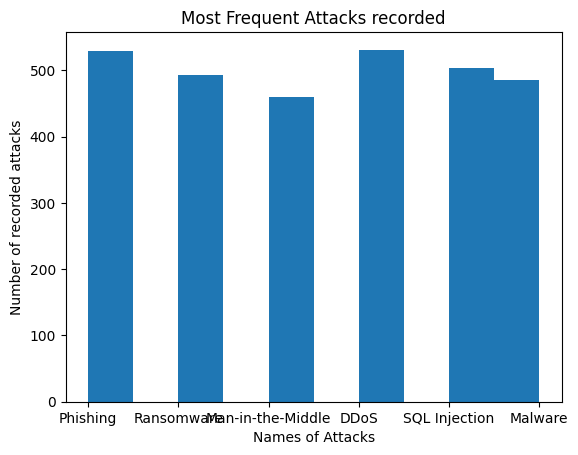

The most frequent Attack Type is DDoS with there being 531 number of attacks in total


In [ ]:
#which attack type is the most frequent attack.

def frequent_type_check():

  return(cb['Attack Type']=='DDoS').sum()

plt.hist(cb['Attack Type'])
plt.xlabel('Names of Attacks')
plt.ylabel('Number of recorded attacks')
plt.title('Most Frequent Attacks recorded')
plt.show()
print(f"The most frequent Attack Type is DDoS with there being {frequent_type_check()} number of attacks in total")


Use monte carlo simulation to predict the outcome of certain attacks since all attacks are random, but prove they are random before doing the simulation


using the law of large numbers we run thousands of simulations to model the uncertainty and estimate the probability of outcomes before they turn into a risk. This is the challenge. Use the data given to run random samples of types of attacks to predict which attacks might be more common in the future and to prepare more for those type of attacks.

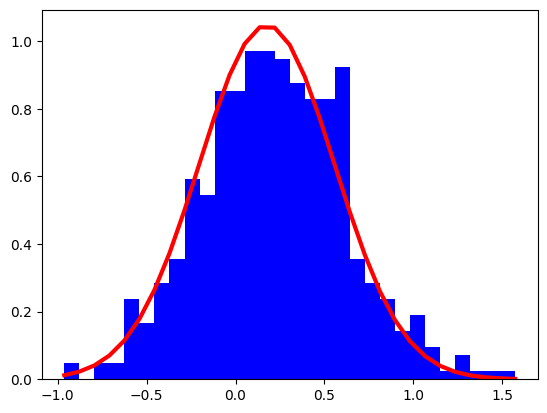

In [ ]:
#created a normal distribution function to be reusable for all attack types in the csv

def normal_distribution_graph(dataMean, dataSTD, dataSize: int):
  dataRS = np.random.normal(dataMean, dataSTD, dataSize)
  count, bins, ignored = plt.hist(dataRS, 30, density=True, color='blue')
  plt.plot(bins, 1/(dataSTD * np.sqrt(2 * np.pi)) *
                np.exp( - (bins - dataMean)**2 / (2 * dataSTD**2) ),
          linewidth=3, color='r')
  plt.show()

phishingMean = (cb['Attack Type']=='Phishing').mean()
phishingSTD = (cb['Attack Type']=='Phishing').std()
size = 500

normal_distribution_graph(phishingMean, phishingSTD, size )

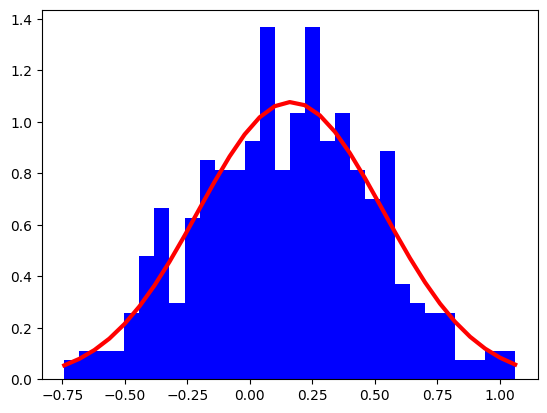

In [ ]:
ransomwareMean = (cb['Attack Type']=='Ransomware').mean()
ransomwareSTD = (cb['Attack Type']=='Ransomware').std()
size: int = 450
normal_distribution_graph(ransomwareMean, ransomwareSTD, size)

In [ ]:
#a function that will help automate the mean and median code instead of manually tpying it.

def all_types_distribution(letter:str, sampleSize:int):

  #uniqueValues = cb['Attack Type'].unique()
  typeDict = {
      'a':'Phishing',
      'b':'Ransomware',
      'c':'Man-in-the-Middle',
      'd':'DDoS',
      'e':'SQL Injection',
      'f':'Malware'
  }

  mean = (cb['Attack Type']==typeDict[letter]).mean()
  standardDeviation = (cb['Attack Type']==typeDict[letter]).std()

  normal_distribution_graph(mean, standardDeviation, sampleSize)


Enter the letter to the corresponding Attack Type

a-Phishing, b-Ransomware, c-Man-in-the-middle, d-DDoS, e-SQL Injection f-Malware
a
Enter The sample size you would like the normal distribution to randomly sample: 
500


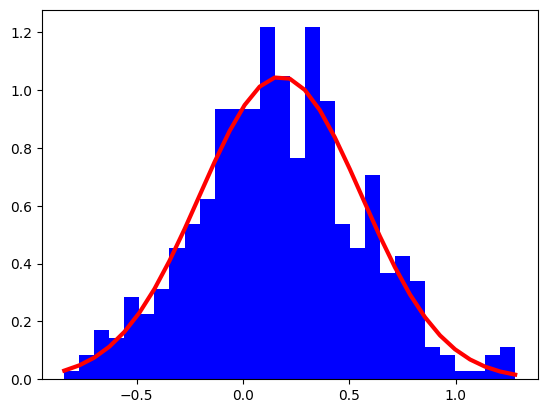

In [ ]:
#user interface code

print('Enter the letter to the corresponding Attack Type\n')
print('a-Phishing, b-Ransomware, c-Man-in-the-middle, d-DDoS, e-SQL Injection', 'f-Malware')

userInputName = str(input())

print('Enter The sample size you would like the normal distribution to randomly sample: ')
userInputSample = int(input())

all_types_distribution(userInputName, userInputSample)

#The real monte carlo prediction simulation to predict what kind attacks are going to be more relevant in the future of cybersecurity attacks.


<Figure size 1500x800 with 0 Axes>

<Figure size 1500x800 with 0 Axes>

<Figure size 1500x800 with 0 Axes>

<Figure size 1500x800 with 0 Axes>

<Figure size 1500x800 with 0 Axes>

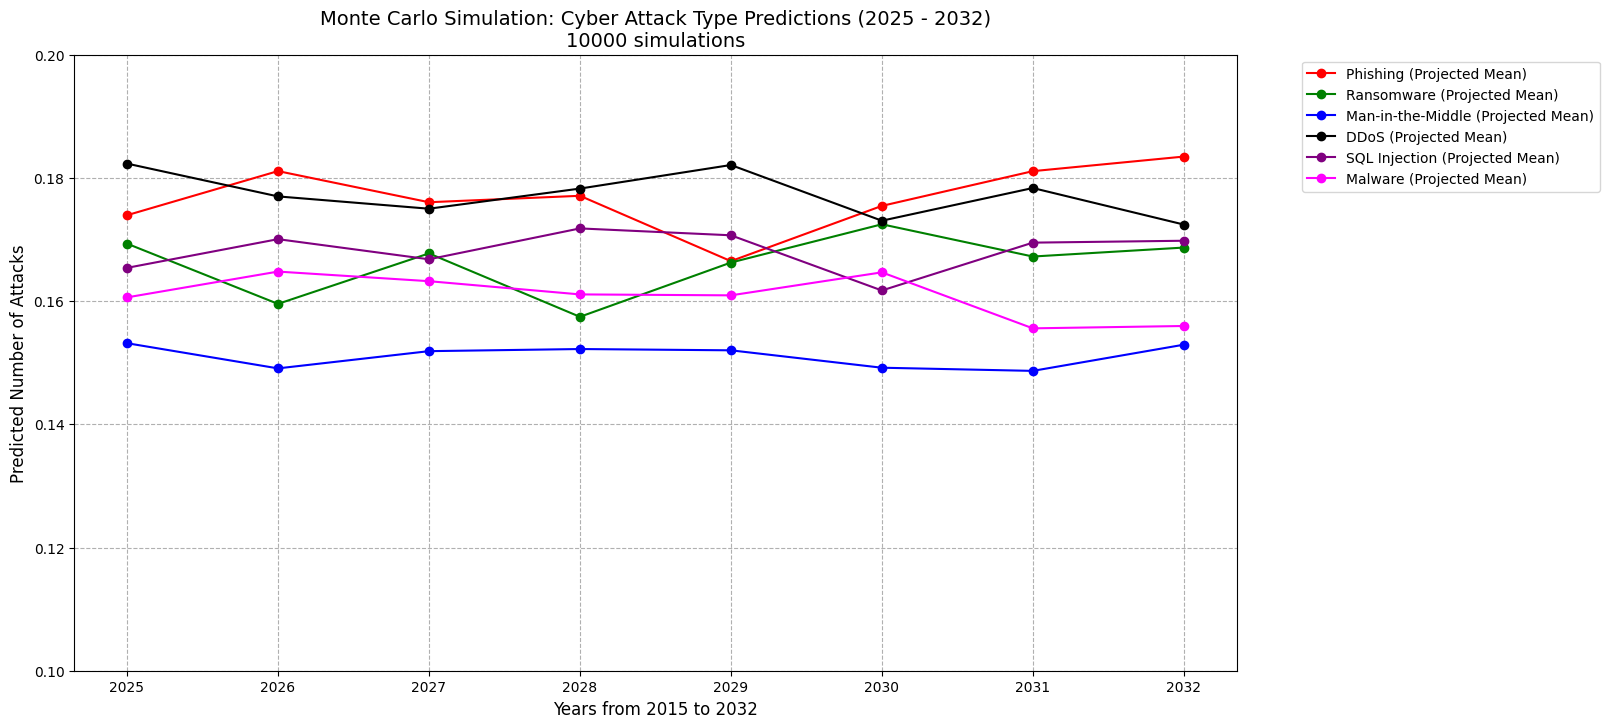

'\nEverytime the propgram is run the lines on the graph will change since it is a random simulation,\nThe one thing we can see is that Phishing and DDoS attacks are most likely going to be the main \ntype of attacks in the future. While Man in the middle and SQL injection attacks are most likely not going to become a common occurence,\nwhile Ransomware seems to spike in some years.\n\nAnother observation is that not all the time but sometimes when running the sim, I see a inverse relationship between Phishing attacks and Ransomware attacks.\n\n'

In [156]:
#monte carlo cybersecurity attacks prediction for the future.
yearsPredict = 8
simulations = 10000
futureYears = np.arange(2025, 2025 + yearsPredict)

results = {}

attackStats = {
    'Phishing': {'mean':(cb['Attack Type']=='Phishing').mean(), 'std':(cb['Attack Type']=='Phishing').std()},
    'Ransomware':{'mean':(cb['Attack Type']=='Ransomware').mean(), 'std':(cb['Attack Type']=='Ransomware').std()},
    'Man-in-the-Middle':{'mean':(cb['Attack Type']=='Man-in-the-Middle').mean(), 'std':(cb['Attack Type']=='Man-in-the-Middle').std()},
    'DDoS':{'mean':(cb['Attack Type']=='DDoS').mean(), 'std':(cb['Attack Type']=='DDoS').std()},
    'SQL Injection':{'mean':(cb['Attack Type']=='SQL Injection').mean(), 'std':(cb['Attack Type']=='SQL Injection').std()},
    'Malware':{'mean':(cb['Attack Type']=='Malware').mean(), 'std':(cb['Attack Type']=='Malware').std()}
}

for attack, stats in attackStats.items():
  sim = np.random.normal(stats['mean'], stats['std'], (simulations, yearsPredict)) #using the random normal function with a tuple of ints
  results[attack] = {
      'mean':np.mean(sim, axis=0),
      'upper':np.percentile(sim, 95, axis=0), #using .percentile() to turn the sim into an array for the specified limits
      'lower':np.percentile(sim, 5, axis=0)
  }
  plt.figure(figsize=(15,8))
  colors = ['r', 'g', 'b', 'black', 'purple', 'magenta']

for i, (attack, data) in enumerate(results.items()):
  plt.plot(futureYears, data['mean'], label=f'{attack} (Projected Mean)',color=colors[i], marker='o')


plt.title(f'Monte Carlo Simulation: Cyber Attack Type Predictions (2025 - 2032)\n{simulations} simulations', fontsize=14)
plt.xlabel("Years from 2025 to 2032", fontsize=12)
plt.ylabel("Predicted Number of Attacks", fontsize=12)
plt.legend(bbox_to_anchor=(1.05,1), loc='upper left')
plt.grid(True, linestyle='--', alpha=1)
plt.ylim(.10, .20)
plt.show()

"""
Everytime the propgram is run the lines on the graph will change since it is a random simulation,
The one thing we can see is that Phishing and DDoS attacks are most likely going to be the main
type of attacks in the future. While Man in the middle and SQL injection attacks are most likely not going to become a common occurence,
while Ransomware seems to spike in some years.

Another observation is that not all the time but sometimes when running the sim, I see a inverse relationship between Phishing attacks and Ransomware attacks.

"""








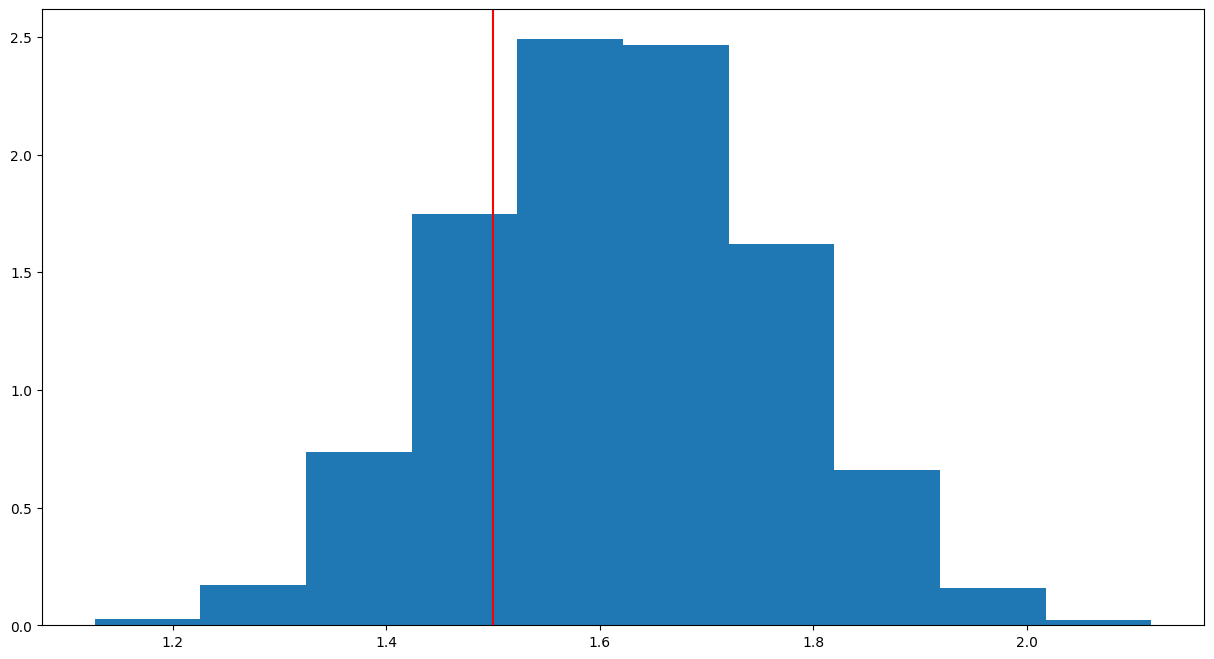

In [158]:
#finding the total histogram or bell shape/curve with all random uniform values and plotting the frequences.
# if you decide to compare this graph to the first normal distribution graphs you are going to see that in the next years there will be an increase
# in attacks for all attacks.

phishing = np.random.uniform((cb['Attack Type']=='Phishing').mean(),(cb['Attack Type']=='Phishing').std(), simulations)
ransomware = np.random.uniform((cb['Attack Type']=='Ransomware').mean(), (cb['Attack Type']=='Ransomware').std(), simulations)
manMiddle = np.random.uniform((cb['Attack Type']=='Man-in-the-Middle').mean(), (cb['Attack Type']=='Man-in-the-Middle').std(), simulations)
ddos = np.random.uniform((cb['Attack Type']=='DDoS').mean(), (cb['Attack Type']=='DDoS').std(), simulations)
sqlInjection = np.random.uniform((cb['Attack Type']=='SQL Injection').mean(), (cb['Attack Type']=='SQL Injection').std(), simulations)
malware = np.random.uniform((cb['Attack Type']=='Malware').mean(), (cb['Attack Type']=='Malware').std(), simulations)

values = (phishing + ransomware + manMiddle + ddos + sqlInjection + malware)

plt.figure(figsize=(15,8))
plt.hist(values, density=True)
plt.axvline(1.50, color='r')
plt.show()
